# Novel Navi Knee (NNK) System - Dynamic Trial Analysis
## Mechanical Axis Derivation from Motion Capture Data

**Date:** 21 November 2025  
---

This notebook processes dynamic motion capture trials to:
1. Estimate Hip Joint Center (HJC) using the Pivot method
2. Calculate Knee Joint Center (KJC) from femoral markers
3. Estimate Ankle Joint Center (AJC) from tibial markers
4. Establish anatomical coordinate frames for femur and tibia
5. Compute the mechanical axis and varus/valgus angles
6. Visualize the lower limb alignment in 3D

## 1. Setup and Data Loading

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
import seaborn as sns
from pathlib import Path
import os

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


### 1.1 Data Loading Functions

In [4]:
def load_vicon_markers(filepath):
    """
    Load Vicon marker data from exported CSV file.
    
    The Vicon CSV has multiple sections:
    - Force plate data at the beginning
    - Marker trajectory data starting at a specific row
    
    Returns:
        DataFrame with marker positions (X, Y, Z) for each marker
    """
    # Find the row where marker data starts
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if 'Subject 1:D1' in line:
                marker_row = i
                break
    
    # Read marker data starting from the identified row
    df = pd.read_csv(filepath, skiprows=marker_row, encoding='latin-1')
    
    # Clean up column names
    df.columns = df.columns.str.strip()
    
    return df

def extract_marker_trajectories(df):
    """
    Extract marker trajectories from the loaded DataFrame.
    
    Returns:
        Dictionary with marker names as keys and (N x 3) arrays as values
    """
    markers = {}
    
    # Define marker names based on your setup
    marker_names = ['D1', 'D2', 'DC', 'DT', 'F3', 'F1', 'FC', 'F4', 'F2', 
                    'T3', 'T1', 'TC', 'T4', 'T2']
    
    for marker in marker_names:
        col_prefix = f'Subject 1:{marker}'
        
        # Find the column with the marker name
        marker_cols = [i for i, col in enumerate(df.columns) if col == col_prefix]
        
        if len(marker_cols) > 0:
            # The marker name column is found, X Y Z data are in the next 3 columns
            marker_col_idx = marker_cols[0]
            
            # Check if there are at least 3 more columns after the marker column
            if marker_col_idx + 3 <= len(df.columns):
                try:
                    # Extract X, Y, Z from the 3 columns immediately after the marker name
                    x = pd.to_numeric(df.iloc[2:, marker_col_idx], errors='coerce').values
                    y = pd.to_numeric(df.iloc[2:, marker_col_idx + 1], errors='coerce').values
                    z = pd.to_numeric(df.iloc[2:, marker_col_idx + 2], errors='coerce').values
                    
                    # Stack into (N x 3) array
                    markers[marker] = np.column_stack([x, y, z])
                except Exception as e:
                    print(f"Warning: Could not extract marker {marker}: {e}")
    
    return markers

# Test data loading
print("Data loading functions defined.")

Data loading functions defined.


### 1.2 Load All Trial Data

In [5]:
# Define file paths
data_dir = Path('data')

files = {
    'static': data_dir / 'Static _trial_with_digitizer.csv',
    'rotation_1': data_dir / 'dynamic _trial_rotation_1.csv',
    'rotation_2': data_dir / 'dynamic _trial_rotation_2.csv',
    'varus_bending': data_dir / 'dynamic _trial_bending&varus_motion 1.csv',
    'lat_femur': data_dir / 'Static_trial_with_digitizer_lat-femur.csv',
    'mid_femur': data_dir / 'Static _trial_with_digitizer_mid_femur.csv',
    'lat_tibia': data_dir / 'Static _trial_with_digitizer_lat_tibial.csv',
    'mid_tibia': data_dir / 'Static _trial_with_digitizer_mid_tibial.csv'
}

# Load all trials
trials = {}
for name, filepath in files.items():
    if filepath.exists():
        print(f"Loading {name}...")
        df = load_vicon_markers(filepath)
        trials[name] = extract_marker_trajectories(df)
        
        # Report what was loaded
        marker_list = list(trials[name].keys())
        if marker_list:
            first_marker = marker_list[0]
            num_frames = len(trials[name][first_marker])
            print(f"  -> Loaded {len(trials[name])} markers: {', '.join(marker_list)}")
            print(f"  -> {num_frames} frames")
        else:
            print(f"  -> Warning: No markers found!")
    else:
        print(f"Warning: {name} file not found at {filepath}")

print("\nAll trials loaded successfully!")

Loading static...
  -> Loaded 14 markers: D1, D2, DC, DT, F3, F1, FC, F4, F2, T3, T1, TC, T4, T2
  -> 297 frames
Loading rotation_1...
  -> Loaded 14 markers: D1, D2, DC, DT, F3, F1, FC, F4, F2, T3, T1, TC, T4, T2
  -> 930 frames
Loading rotation_2...
  -> Loaded 14 markers: D1, D2, DC, DT, F3, F1, FC, F4, F2, T3, T1, TC, T4, T2
  -> 934 frames
Loading varus_bending...
  -> Loaded 14 markers: D1, D2, DC, DT, F3, F1, FC, F4, F2, T3, T1, TC, T4, T2
  -> 595 frames
Loading lat_femur...
  -> Loaded 14 markers: D1, D2, DC, DT, F3, F1, FC, F4, F2, T3, T1, TC, T4, T2
  -> 180 frames
Loading mid_femur...
  -> Loaded 14 markers: D1, D2, DC, DT, F3, F1, FC, F4, F2, T3, T1, TC, T4, T2
  -> 205 frames
Loading lat_tibia...
  -> Loaded 14 markers: D1, D2, DC, DT, F3, F1, FC, F4, F2, T3, T1, TC, T4, T2
  -> 165 frames
Loading mid_tibia...
  -> Loaded 14 markers: D1, D2, DC, DT, F3, F1, FC, F4, F2, T3, T1, TC, T4, T2
  -> 180 frames

All trials loaded successfully!


## 2. Digitizer Calibration and Anatomical Landmark Registration

The digitizer has markers DC (center) and DT (tip). We use the static trials where the digitizer points to anatomical landmarks to register:
- Lateral femoral epicondyle
- Medial femoral epicondyle (mid_femur in your naming)
- Lateral tibial plateau/condyle
- Medial tibial plateau/condyle (mid_tibia in your naming)

In [6]:
def calculate_digitizer_tip(markers, avg_frames=50):
    """
    Calculate the position of the digitizer tip (DT) in the static trial.
    
    Args:
        markers: Dictionary of marker trajectories
        avg_frames: Number of frames to average (assuming stable pointing)
    
    Returns:
        Mean position of digitizer tip (3D point)
    """
    # Use middle portion of the trial for stability
    dt_traj = markers['DT']
    n_frames = len(dt_traj)
    
    # Remove NaN values
    valid_frames = ~np.isnan(dt_traj).any(axis=1)
    dt_valid = dt_traj[valid_frames]
    
    # Take middle section
    mid_start = len(dt_valid) // 2 - avg_frames // 2
    mid_end = mid_start + avg_frames
    
    dt_mean = np.mean(dt_valid[mid_start:mid_end], axis=0)
    dt_std = np.std(dt_valid[mid_start:mid_end], axis=0)
    
    print(f"  Digitizer tip position: {dt_mean}")
    print(f"  Standard deviation: {dt_std} mm")
    
    return dt_mean

# Register anatomical landmarks using digitizer
anatomical_landmarks = {}

print("Registering anatomical landmarks...\n")

landmark_trials = {
    'lateral_femoral_epicondyle': 'lat_femur',
    'medial_femoral_epicondyle': 'mid_femur',
    'lateral_tibial_plateau': 'lat_tibia',
    'medial_tibial_plateau': 'mid_tibia'
}

for landmark, trial_name in landmark_trials.items():
    if trial_name in trials:
        print(f"{landmark}:")
        anatomical_landmarks[landmark] = calculate_digitizer_tip(trials[trial_name])
        print()

print("Anatomical landmarks registered!")

Registering anatomical landmarks...

lateral_femoral_epicondyle:
  Digitizer tip position: [254.03546  377.37634   21.847572]
  Standard deviation: [0.02988592 0.0572687  0.02785112] mm

medial_femoral_epicondyle:
  Digitizer tip position: [-63.45235  340.08712   74.366344]
  Standard deviation: [0.07641778 0.14265674 0.15718105] mm

lateral_tibial_plateau:
  Digitizer tip position: [253.85112  353.40216   25.915368]
  Standard deviation: [0.02977559 0.07428657 0.09453913] mm

medial_tibial_plateau:
  Digitizer tip position: [-44.266096 261.2831    80.662836]
  Standard deviation: [0.01781314 0.0151225  0.01731352] mm

Anatomical landmarks registered!


## 3. Hip Joint Center (HJC) Estimation - Pivot Method

The Pivot method estimates the HJC by finding the center of rotation during hip rotation movements.
We use femoral markers (F1-F4, FC) that move with the femur during hip rotation.

**Reference:** Siston & Delp (2006), Larose et al. (2019)

In [7]:
def pivot_method_hjc(femur_markers_list, method='sphere_fit'):
    """
    Estimate Hip Joint Center using the Pivot method.
    
    Args:
        femur_markers_list: List of marker trajectories (each is N x 3)
        method: 'sphere_fit' or 'optimization'
    
    Returns:
        hjc: Estimated hip joint center (3D point)
        precision: Precision metric (standard deviation of residuals)
    """
    # Concatenate all marker positions from all trials
    all_points = []
    
    for markers in femur_markers_list:
        # Remove NaN values
        valid = ~np.isnan(markers).any(axis=1)
        all_points.append(markers[valid])
    
    all_points = np.vstack(all_points)
    
    print(f"Total points for HJC estimation: {len(all_points)}")
    
    if method == 'sphere_fit':
        # Sphere fitting approach
        # The center of the sphere is the HJC
        
        def sphere_residuals(params, points):
            """Residuals for sphere fitting"""
            cx, cy, cz, r = params
            center = np.array([cx, cy, cz])
            distances = np.linalg.norm(points - center, axis=1)
            return distances - r
        
        # Initial guess: centroid of all points
        initial_center = np.mean(all_points, axis=0)
        initial_radius = np.mean(np.linalg.norm(all_points - initial_center, axis=1))
        initial_params = np.append(initial_center, initial_radius)
        
        # Optimize
        result = least_squares(sphere_residuals, initial_params, args=(all_points,))
        
        hjc = result.x[:3]
        radius = result.x[3]
        
        # Calculate precision
        residuals = sphere_residuals(result.x, all_points)
        precision = np.std(residuals)
        
        print(f"\nHJC Estimation Results:")
        print(f"  Position: [{hjc[0]:.2f}, {hjc[1]:.2f}, {hjc[2]:.2f}] mm")
        print(f"  Sphere radius: {radius:.2f} mm")
        print(f"  Precision (SD of residuals): {precision:.2f} mm")
        print(f"  Mean residual: {np.mean(np.abs(residuals)):.2f} mm")
        
        return hjc, precision

# Collect femoral marker trajectories from rotation trials
femur_marker_names = ['F1', 'F2', 'F3', 'F4', 'FC']
femur_trajectories = []

for trial_name in ['rotation_1', 'rotation_2']:
    if trial_name in trials:
        for marker_name in femur_marker_names:
            if marker_name in trials[trial_name]:
                femur_trajectories.append(trials[trial_name][marker_name])

print(f"Using {len(femur_trajectories)} femoral marker trajectories for HJC estimation\n")

# Estimate HJC
hjc, hjc_precision = pivot_method_hjc(femur_trajectories)

print(f"\n✓ Hip Joint Center estimated with {hjc_precision:.2f} mm precision")

Using 10 femoral marker trajectories for HJC estimation

Total points for HJC estimation: 9320

HJC Estimation Results:
  Position: [53.91, 465.38, 286.80] mm
  Sphere radius: 84.57 mm
  Precision (SD of residuals): 31.07 mm
  Mean residual: 25.62 mm

✓ Hip Joint Center estimated with 31.07 mm precision


## 4. Knee Joint Center (KJC) Estimation

The KJC is estimated as the midpoint between the medial and lateral femoral epicondyles.

In [8]:
def estimate_kjc(lateral_epicondyle, medial_epicondyle):
    """
    Estimate Knee Joint Center as midpoint between epicondyles.
    
    Args:
        lateral_epicondyle: 3D position of lateral femoral epicondyle
        medial_epicondyle: 3D position of medial femoral epicondyle
    
    Returns:
        kjc: Knee joint center (3D point)
    """
    kjc = (lateral_epicondyle + medial_epicondyle) / 2.0
    
    # Calculate inter-epicondylar distance
    epicondylar_width = np.linalg.norm(lateral_epicondyle - medial_epicondyle)
    
    print(f"Knee Joint Center Estimation:")
    print(f"  Lateral epicondyle: {lateral_epicondyle}")
    print(f"  Medial epicondyle: {medial_epicondyle}")
    print(f"  Inter-epicondylar width: {epicondylar_width:.2f} mm")
    print(f"  KJC position: [{kjc[0]:.2f}, {kjc[1]:.2f}, {kjc[2]:.2f}] mm")
    
    return kjc

# Estimate KJC from anatomical landmarks
kjc = estimate_kjc(
    anatomical_landmarks['lateral_femoral_epicondyle'],
    anatomical_landmarks['medial_femoral_epicondyle']
)

print("\n✓ Knee Joint Center estimated")

Knee Joint Center Estimation:
  Lateral epicondyle: [254.03546  377.37634   21.847572]
  Medial epicondyle: [-63.45235  340.08712   74.366344]
  Inter-epicondylar width: 323.96 mm
  KJC position: [95.29, 358.73, 48.11] mm

✓ Knee Joint Center estimated


## 5. Ankle Joint Center (AJC) Estimation

Since there are no markers on the malleoli, we estimate the AJC using:
1. **Method 1:** Midpoint between registered tibial plateau points, projected distally
2. **Method 2:** Estimate based on tibial marker cluster and typical ankle-to-knee distance ratio

For the NNK system, we'll use a combination approach based on tibial plateau width and anatomical proportions.

In [9]:
def estimate_ajc(kjc, lateral_tibial_plateau, medial_tibial_plateau, tibia_markers=None):
    """
    Estimate Ankle Joint Center from tibial landmarks.
    
    Args:
        kjc: Knee joint center
        lateral_tibial_plateau: Position of lateral tibial plateau
        medial_tibial_plateau: Position of medial tibial plateau
        tibia_markers: Optional dictionary of tibial marker trajectories for refinement
    
    Returns:
        ajc: Estimated ankle joint center (3D point)
    """
    # Method 1: Use tibial plateau midpoint and project along tibial axis
    tibial_plateau_center = (lateral_tibial_plateau + medial_tibial_plateau) / 2.0
    
    # Define tibial longitudinal axis (from KJC to tibial plateau center)
    tibial_axis = tibial_plateau_center - kjc
    tibial_axis_normalized = tibial_axis / np.linalg.norm(tibial_axis)
    
    # Estimate tibial length based on typical anthropometric ratios
    # Typical tibial length is approximately 85% of femoral length
    # Or we can use a standard ratio of knee-to-ankle distance
    
    # Calculate knee to tibial plateau distance
    knee_to_plateau_dist = np.linalg.norm(kjc - tibial_plateau_center)
    
    # Typical tibial length (from plateau to malleoli) is ~350-400mm for adults
    # We'll estimate based on the plateau position relative to KJC
    estimated_tibial_length = 380  # mm, typical value
    
    # If tibia markers are available, refine estimate
    if tibia_markers is not None:
        # Use distal tibial markers to refine
        # Get mean position of tibial markers
        t_markers = []
        for marker in ['T1', 'T2', 'T3', 'T4', 'TC']:
            if marker in tibia_markers:
                valid = ~np.isnan(tibia_markers[marker]).any(axis=1)
                t_markers.append(np.mean(tibia_markers[marker][valid], axis=0))
        
        if t_markers:
            tibia_cluster_center = np.mean(t_markers, axis=0)
            
            # Estimate AJC as projection from tibia cluster center
            cluster_to_kjc = kjc - tibia_cluster_center
            cluster_dist = np.linalg.norm(cluster_to_kjc)
            
            # AJC is approximately at the level below the cluster
            # Assuming cluster is mid-tibia, project further down
            ajc_offset = 150  # mm below cluster center (approximate)
            ajc = tibia_cluster_center - tibial_axis_normalized * ajc_offset
    else:
        # Project from tibial plateau center along tibial axis
        ajc = tibial_plateau_center - tibial_axis_normalized * estimated_tibial_length
    
    # Calculate ankle width (approximate as ~70% of tibial plateau width)
    tibial_plateau_width = np.linalg.norm(lateral_tibial_plateau - medial_tibial_plateau)
    estimated_ankle_width = tibial_plateau_width * 0.7
    
    print(f"\nAnkle Joint Center Estimation:")
    print(f"  Tibial plateau width: {tibial_plateau_width:.2f} mm")
    print(f"  Estimated ankle width: {estimated_ankle_width:.2f} mm")
    print(f"  AJC position: [{ajc[0]:.2f}, {ajc[1]:.2f}, {ajc[2]:.2f}] mm")
    print(f"  Note: AJC estimated without malleoli markers (use with caution)")
    
    return ajc

# Get tibial markers from static trial for refinement
tibia_markers_static = {k: v for k, v in trials['static'].items() if k.startswith('T')}

# Estimate AJC
ajc = estimate_ajc(
    kjc,
    anatomical_landmarks['lateral_tibial_plateau'],
    anatomical_landmarks['medial_tibial_plateau'],
    tibia_markers_static
)

print("\n✓ Ankle Joint Center estimated")


Ankle Joint Center Estimation:
  Tibial plateau width: 316.79 mm
  Estimated ankle width: 221.75 mm
  AJC position: [39.41, 336.09, 217.45] mm
  Note: AJC estimated without malleoli markers (use with caution)

✓ Ankle Joint Center estimated


## 6. Anatomical Coordinate Frames

Establish anatomical coordinate frames for femur and tibia based on ISB recommendations.

**Femoral Coordinate System:**
- Origin: KJC
- Y-axis: Along femoral shaft (KJC to HJC)
- X-axis: Medial-lateral (perpendicular to Y, in frontal plane)
- Z-axis: Anterior-posterior (cross product)

**Tibial Coordinate System:**
- Origin: KJC
- Y-axis: Along tibial shaft (KJC to AJC)
- X-axis: Medial-lateral (perpendicular to Y)
- Z-axis: Anterior-posterior

In [10]:
def create_anatomical_frame(proximal_jc, distal_jc, lateral_point, medial_point):
    """
    Create anatomical coordinate frame for a bone segment.
    
    Args:
        proximal_jc: Proximal joint center
        distal_jc: Distal joint center
        lateral_point: Lateral anatomical landmark
        medial_point: Medial anatomical landmark
    
    Returns:
        R: 3x3 rotation matrix [X, Y, Z] where columns are unit vectors
        origin: Origin of coordinate frame
    """
    # Origin at distal joint
    origin = distal_jc
    
    # Y-axis: longitudinal axis (distal to proximal)
    y_axis = proximal_jc - distal_jc
    y_axis = y_axis / np.linalg.norm(y_axis)
    
    # X-axis: medial-lateral direction
    # Vector from medial to lateral
    ml_vector = lateral_point - medial_point
    
    # Make X perpendicular to Y (project ML vector onto plane perpendicular to Y)
    x_axis = ml_vector - np.dot(ml_vector, y_axis) * y_axis
    x_axis = x_axis / np.linalg.norm(x_axis)
    
    # Z-axis: anterior-posterior (cross product)
    z_axis = np.cross(x_axis, y_axis)
    z_axis = z_axis / np.linalg.norm(z_axis)
    
    # Rotation matrix
    R = np.column_stack([x_axis, y_axis, z_axis])
    
    return R, origin

# Create femoral coordinate frame
print("Creating Femoral Coordinate Frame...")
R_femur, origin_femur = create_anatomical_frame(
    hjc,  # proximal
    kjc,  # distal
    anatomical_landmarks['lateral_femoral_epicondyle'],
    anatomical_landmarks['medial_femoral_epicondyle']
)

print(f"  Origin: {origin_femur}")
print(f"  X-axis (lateral): {R_femur[:, 0]}")
print(f"  Y-axis (longitudinal): {R_femur[:, 1]}")
print(f"  Z-axis (anterior): {R_femur[:, 2]}")

# Create tibial coordinate frame
print("\nCreating Tibial Coordinate Frame...")
R_tibia, origin_tibia = create_anatomical_frame(
    kjc,  # proximal
    ajc,  # distal
    anatomical_landmarks['lateral_tibial_plateau'],
    anatomical_landmarks['medial_tibial_plateau']
)

print(f"  Origin: {origin_tibia}")
print(f"  X-axis (lateral): {R_tibia[:, 0]}")
print(f"  Y-axis (longitudinal): {R_tibia[:, 1]}")
print(f"  Z-axis (anterior): {R_tibia[:, 2]}")

print("\n✓ Anatomical coordinate frames established")

Creating Femoral Coordinate Frame...
  Origin: [ 95.291555 358.73173   48.106958]
  X-axis (lateral): [0.97211019 0.2243603  0.06829516]
  Y-axis (longitudinal): [-0.15634485  0.40290863  0.90178762]
  Z-axis (anterior): [ 0.17480863 -0.88731454  0.42674917]

Creating Tibial Coordinate Frame...
  Origin: [ 39.40813222 336.08828337 217.45309373]
  X-axis (lateral): [0.90523866 0.262823   0.3338668 ]
  Y-axis (longitudinal): [ 0.3108773   0.12596461 -0.94206593]
  Z-axis (anterior): [-0.289652    0.95658611  0.03232233]

✓ Anatomical coordinate frames established


## 7. Mechanical Axis Calculation

The mechanical axis is the line from HJC to AJC, passing through the knee.
This represents the load-bearing axis of the lower limb.

In [11]:
def calculate_mechanical_axis(hjc, kjc, ajc):
    """
    Calculate the mechanical axis of the lower limb.
    
    Args:
        hjc: Hip joint center
        kjc: Knee joint center
        ajc: Ankle joint center
    
    Returns:
        mechanical_axis: Unit vector from HJC to AJC
        axis_length: Total length of mechanical axis
        knee_offset: Perpendicular distance from KJC to mechanical axis
    """
    # Mechanical axis vector
    mechanical_axis = ajc - hjc
    axis_length = np.linalg.norm(mechanical_axis)
    mechanical_axis_unit = mechanical_axis / axis_length
    
    # Calculate knee offset (how far KJC is from mechanical axis)
    # Project KJC onto mechanical axis
    hjc_to_kjc = kjc - hjc
    projection_length = np.dot(hjc_to_kjc, mechanical_axis_unit)
    projection_point = hjc + projection_length * mechanical_axis_unit
    
    knee_offset_vector = kjc - projection_point
    knee_offset = np.linalg.norm(knee_offset_vector)
    
    # Determine direction of offset (medial or lateral)
    # Use femoral X-axis (lateral direction)
    offset_sign = np.sign(np.dot(knee_offset_vector, R_femur[:, 0]))
    knee_offset_signed = knee_offset * offset_sign
    
    print(f"Mechanical Axis Analysis:")
    print(f"  Total length (HJC to AJC): {axis_length:.2f} mm")
    print(f"  Femur length (HJC to KJC): {np.linalg.norm(kjc - hjc):.2f} mm")
    print(f"  Tibia length (KJC to AJC): {np.linalg.norm(ajc - kjc):.2f} mm")
    print(f"  Knee offset from mechanical axis: {knee_offset:.2f} mm")
    print(f"  Offset direction: {'Lateral' if offset_sign > 0 else 'Medial'}")
    print(f"  Normal knee offset is typically < 20 mm")
    
    return mechanical_axis_unit, axis_length, knee_offset_signed

# Calculate mechanical axis
mech_axis, mech_axis_length, knee_offset = calculate_mechanical_axis(hjc, kjc, ajc)

print("\n✓ Mechanical axis calculated")

Mechanical Axis Analysis:
  Total length (HJC to AJC): 147.43 mm
  Femur length (HJC to KJC): 264.69 mm
  Tibia length (KJC to AJC): 179.76 mm
  Knee offset from mechanical axis: 171.36 mm
  Offset direction: Lateral
  Normal knee offset is typically < 20 mm

✓ Mechanical axis calculated


## 8. Varus/Valgus Angle Calculation

Calculate the frontal plane alignment angle:
- 180° = Perfect alignment
- > 180° = Valgus (knock-knee)
- < 180° = Varus (bow-legged)

In [12]:
def calculate_varus_valgus_angle(hjc, kjc, ajc, R_femur):
    """
    Calculate varus/valgus angle in the frontal plane.
    
    Args:
        hjc: Hip joint center
        kjc: Knee joint center  
        ajc: Ankle joint center
        R_femur: Femoral coordinate frame (for determining frontal plane)
    
    Returns:
        vv_angle: Varus/valgus angle in degrees
        alignment_type: 'Varus', 'Neutral', or 'Valgus'
    """
    # Project points onto frontal plane (defined by X and Y axes of femur)
    # Frontal plane normal is Z-axis (anterior-posterior)
    frontal_normal = R_femur[:, 2]
    
    # Project HJC, KJC, AJC onto frontal plane
    # (Remove component along frontal normal)
    def project_to_frontal(point, reference_point, normal):
        vec = point - reference_point
        projection = vec - np.dot(vec, normal) * normal
        return reference_point + projection
    
    hjc_frontal = project_to_frontal(hjc, kjc, frontal_normal)
    kjc_frontal = kjc  # Already on frontal plane (reference)
    ajc_frontal = project_to_frontal(ajc, kjc, frontal_normal)
    
    # Calculate angle between femoral and tibial mechanical axes in frontal plane
    femur_vec = hjc_frontal - kjc_frontal
    tibia_vec = ajc_frontal - kjc_frontal
    
    # Normalize vectors
    femur_vec = femur_vec / np.linalg.norm(femur_vec)
    tibia_vec = tibia_vec / np.linalg.norm(tibia_vec)
    
    # Calculate angle
    cos_angle = np.dot(femur_vec, tibia_vec)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)  # Numerical stability
    angle_rad = np.arccos(cos_angle)
    angle_deg = np.degrees(angle_rad)
    
    # Determine if varus or valgus
    # Cross product to determine direction
    cross = np.cross(femur_vec, tibia_vec)
    direction = np.dot(cross, frontal_normal)
    
    # Convention: angle measured as supplementary angle for clinical interpretation
    vv_angle = 180 - angle_deg if direction > 0 else 180 + angle_deg
    
    # Classify alignment
    if vv_angle < 175:
        alignment_type = 'Varus'
    elif vv_angle > 185:
        alignment_type = 'Valgus'
    else:
        alignment_type = 'Neutral'
    
    print(f"\nVarus/Valgus Angle Analysis:")
    print(f"  Frontal plane angle: {vv_angle:.2f}°")
    print(f"  Deviation from neutral (180°): {vv_angle - 180:.2f}°")
    print(f"  Alignment classification: {alignment_type}")
    print(f"\n  Clinical Interpretation:")
    print(f"    180° = Perfect alignment")
    print(f"    >180° = Valgus (knock-knee)")
    print(f"    <180° = Varus (bow-legged)")
    
    return vv_angle, alignment_type

# Calculate varus/valgus angle
vv_angle, alignment_type = calculate_varus_valgus_angle(hjc, kjc, ajc, R_femur)

print("\n✓ Varus/valgus angle calculated")


Varus/Valgus Angle Analysis:
  Frontal plane angle: 162.56°
  Deviation from neutral (180°): -17.44°
  Alignment classification: Varus

  Clinical Interpretation:
    180° = Perfect alignment
    >180° = Valgus (knock-knee)
    <180° = Varus (bow-legged)

✓ Varus/valgus angle calculated


## 9. 3D Visualization of Lower Limb and Mechanical Axis

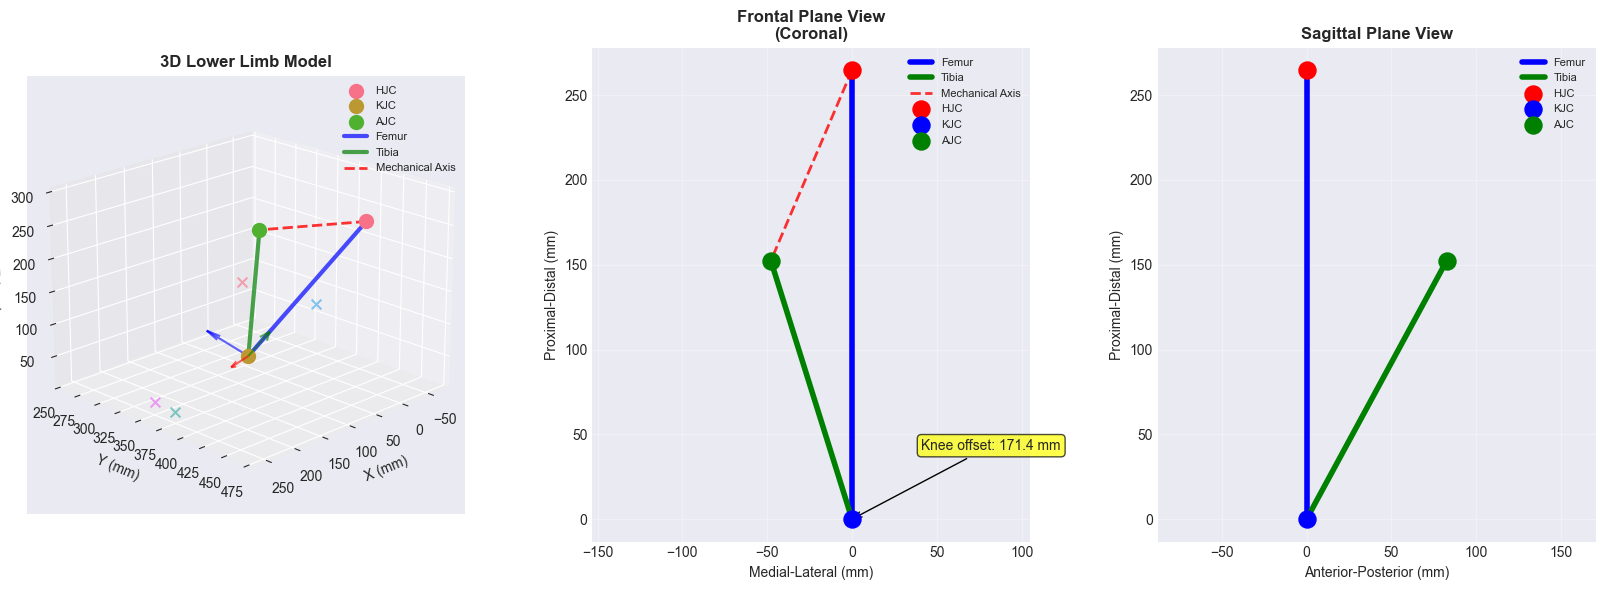


✓ 3D visualization saved


In [13]:
def plot_lower_limb_3d(hjc, kjc, ajc, R_femur, R_tibia, anatomical_landmarks, 
                       mech_axis_unit, knee_offset):
    """
    Create 3D visualization of lower limb with mechanical axis.
    """
    fig = plt.figure(figsize=(16, 6))
    
    # 3D view
    ax1 = fig.add_subplot(131, projection='3d')
    
    # Plot joint centers
    joints = {'HJC': hjc, 'KJC': kjc, 'AJC': ajc}
    for name, pos in joints.items():
        ax1.scatter(*pos, s=100, label=name, zorder=5)
    
    # Plot bone segments
    ax1.plot([hjc[0], kjc[0]], [hjc[1], kjc[1]], [hjc[2], kjc[2]], 
             'b-', linewidth=3, label='Femur', alpha=0.7)
    ax1.plot([kjc[0], ajc[0]], [kjc[1], ajc[1]], [kjc[2], ajc[2]], 
             'g-', linewidth=3, label='Tibia', alpha=0.7)
    
    # Plot mechanical axis
    ax1.plot([hjc[0], ajc[0]], [hjc[1], ajc[1]], [hjc[2], ajc[2]], 
             'r--', linewidth=2, label='Mechanical Axis', alpha=0.8)
    
    # Plot anatomical landmarks
    for name, pos in anatomical_landmarks.items():
        ax1.scatter(*pos, s=50, marker='x', alpha=0.6)
    
    # Plot coordinate frames
    scale = 50  # mm
    colors = ['r', 'g', 'b']
    labels = ['X (Lat)', 'Y (Long)', 'Z (Ant)']
    
    for i in range(3):
        # Femoral frame
        ax1.quiver(kjc[0], kjc[1], kjc[2],
                  R_femur[0, i] * scale, R_femur[1, i] * scale, R_femur[2, i] * scale,
                  color=colors[i], alpha=0.6, arrow_length_ratio=0.3)
    
    ax1.set_xlabel('X (mm)')
    ax1.set_ylabel('Y (mm)')
    ax1.set_zlabel('Z (mm)')
    ax1.set_title('3D Lower Limb Model', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.view_init(elev=20, azim=45)
    
    # Frontal plane view
    ax2 = fig.add_subplot(132)
    
    # Project to frontal plane (X-Y plane of femoral frame)
    frontal_normal = R_femur[:, 2]
    
    def project_to_2d(point):
        # Project onto X-Y plane of femoral frame
        x = np.dot(point - kjc, R_femur[:, 0])
        y = np.dot(point - kjc, R_femur[:, 1])
        return x, y
    
    hjc_2d = project_to_2d(hjc)
    kjc_2d = (0, 0)  # Origin
    ajc_2d = project_to_2d(ajc)
    
    # Plot bones
    ax2.plot([hjc_2d[0], kjc_2d[0]], [hjc_2d[1], kjc_2d[1]], 
             'b-', linewidth=4, label='Femur')
    ax2.plot([kjc_2d[0], ajc_2d[0]], [kjc_2d[1], ajc_2d[1]], 
             'g-', linewidth=4, label='Tibia')
    
    # Plot mechanical axis
    ax2.plot([hjc_2d[0], ajc_2d[0]], [hjc_2d[1], ajc_2d[1]], 
             'r--', linewidth=2, label='Mechanical Axis', alpha=0.8)
    
    # Plot joint centers
    ax2.scatter(*hjc_2d, s=150, c='red', marker='o', label='HJC', zorder=5)
    ax2.scatter(*kjc_2d, s=150, c='blue', marker='o', label='KJC', zorder=5)
    ax2.scatter(*ajc_2d, s=150, c='green', marker='o', label='AJC', zorder=5)
    
    # Add knee offset annotation
    ax2.annotate(f'Knee offset: {knee_offset:.1f} mm',
                xy=kjc_2d, xytext=(50, 50),
                textcoords='offset points',
                bbox=dict(boxstyle='round', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    ax2.set_xlabel('Medial-Lateral (mm)', fontsize=10)
    ax2.set_ylabel('Proximal-Distal (mm)', fontsize=10)
    ax2.set_title('Frontal Plane View\n(Coronal)', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    # Sagittal plane view
    ax3 = fig.add_subplot(133)
    
    def project_to_sagittal(point):
        # Project onto Y-Z plane of femoral frame
        z = np.dot(point - kjc, R_femur[:, 2])
        y = np.dot(point - kjc, R_femur[:, 1])
        return z, y
    
    hjc_sag = project_to_sagittal(hjc)
    kjc_sag = (0, 0)
    ajc_sag = project_to_sagittal(ajc)
    
    # Plot bones
    ax3.plot([hjc_sag[0], kjc_sag[0]], [hjc_sag[1], kjc_sag[1]], 
             'b-', linewidth=4, label='Femur')
    ax3.plot([kjc_sag[0], ajc_sag[0]], [kjc_sag[1], ajc_sag[1]], 
             'g-', linewidth=4, label='Tibia')
    
    # Plot joint centers
    ax3.scatter(*hjc_sag, s=150, c='red', marker='o', label='HJC', zorder=5)
    ax3.scatter(*kjc_sag, s=150, c='blue', marker='o', label='KJC', zorder=5)
    ax3.scatter(*ajc_sag, s=150, c='green', marker='o', label='AJC', zorder=5)
    
    ax3.set_xlabel('Anterior-Posterior (mm)', fontsize=10)
    ax3.set_ylabel('Proximal-Distal (mm)', fontsize=10)
    ax3.set_title('Sagittal Plane View', fontsize=12, fontweight='bold')
    ax3.legend(loc='upper right', fontsize=8)
    ax3.grid(True, alpha=0.3)
    ax3.axis('equal')
    
    plt.tight_layout()
    plt.savefig('./outputs/mechanical_axis_3d_visualization.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ 3D visualization saved")

# Create visualization
plot_lower_limb_3d(hjc, kjc, ajc, R_femur, R_tibia, anatomical_landmarks, 
                   mech_axis, knee_offset)

## 10. Summary Report and Export

In [14]:
# Create comprehensive summary
summary = {
    'Joint Centers': {
        'HJC (mm)': hjc.tolist(),
        'KJC (mm)': kjc.tolist(),
        'AJC (mm)': ajc.tolist(),
        'HJC Precision (mm)': float(hjc_precision)
    },
    'Segment Lengths': {
        'Femur (mm)': float(np.linalg.norm(kjc - hjc)),
        'Tibia (mm)': float(np.linalg.norm(ajc - kjc)),
        'Total (mm)': float(mech_axis_length)
    },
    'Mechanical Axis': {
        'Knee Offset (mm)': float(knee_offset),
        'Offset Status': 'Normal' if abs(knee_offset) < 20 else 'Abnormal'
    },
    'Alignment': {
        'Varus/Valgus Angle (deg)': float(vv_angle),
        'Deviation from Neutral (deg)': float(vv_angle - 180),
        'Classification': alignment_type
    },
    'Anatomical Landmarks': {
        k: v.tolist() for k, v in anatomical_landmarks.items()
    }
}

# Print formatted summary
print("="*60)
print("NNK SYSTEM - MECHANICAL AXIS ANALYSIS SUMMARY")
print("="*60)
print("\nJOINT CENTERS:")
print(f"  Hip (HJC):    [{hjc[0]:7.2f}, {hjc[1]:7.2f}, {hjc[2]:7.2f}] mm")
print(f"  Knee (KJC):   [{kjc[0]:7.2f}, {kjc[1]:7.2f}, {kjc[2]:7.2f}] mm")
print(f"  Ankle (AJC):  [{ajc[0]:7.2f}, {ajc[1]:7.2f}, {ajc[2]:7.2f}] mm")
print(f"  HJC Precision: {hjc_precision:.2f} mm")

print("\nSEGMENT LENGTHS:")
print(f"  Femur:  {np.linalg.norm(kjc - hjc):.2f} mm")
print(f"  Tibia:  {np.linalg.norm(ajc - kjc):.2f} mm")
print(f"  Total:  {mech_axis_length:.2f} mm")

print("\nMECHANICAL AXIS:")
print(f"  Knee Offset: {knee_offset:.2f} mm ({'Lateral' if knee_offset > 0 else 'Medial'})")
print(f"  Status: {'✓ Normal' if abs(knee_offset) < 20 else '⚠ Abnormal'} (threshold: 20mm)")

print("\nALIGNMENT:")
print(f"  Varus/Valgus Angle: {vv_angle:.2f}°")
print(f"  Deviation: {vv_angle - 180:+.2f}° from neutral")
print(f"  Classification: {alignment_type}")

print("\n" + "="*60)

# Export to CSV
import json

# Save as JSON
with open('./outputs/nnk_analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Save as CSV for easy import
results_df = pd.DataFrame([
    {'Parameter': 'HJC_X', 'Value': hjc[0], 'Unit': 'mm'},
    {'Parameter': 'HJC_Y', 'Value': hjc[1], 'Unit': 'mm'},
    {'Parameter': 'HJC_Z', 'Value': hjc[2], 'Unit': 'mm'},
    {'Parameter': 'HJC_Precision', 'Value': hjc_precision, 'Unit': 'mm'},
    {'Parameter': 'KJC_X', 'Value': kjc[0], 'Unit': 'mm'},
    {'Parameter': 'KJC_Y', 'Value': kjc[1], 'Unit': 'mm'},
    {'Parameter': 'KJC_Z', 'Value': kjc[2], 'Unit': 'mm'},
    {'Parameter': 'AJC_X', 'Value': ajc[0], 'Unit': 'mm'},
    {'Parameter': 'AJC_Y', 'Value': ajc[1], 'Unit': 'mm'},
    {'Parameter': 'AJC_Z', 'Value': ajc[2], 'Unit': 'mm'},
    {'Parameter': 'Femur_Length', 'Value': np.linalg.norm(kjc - hjc), 'Unit': 'mm'},
    {'Parameter': 'Tibia_Length', 'Value': np.linalg.norm(ajc - kjc), 'Unit': 'mm'},
    {'Parameter': 'Mechanical_Axis_Length', 'Value': mech_axis_length, 'Unit': 'mm'},
    {'Parameter': 'Knee_Offset', 'Value': knee_offset, 'Unit': 'mm'},
    {'Parameter': 'Varus_Valgus_Angle', 'Value': vv_angle, 'Unit': 'degrees'},
    {'Parameter': 'Alignment_Type', 'Value': alignment_type, 'Unit': '-'}
])

results_df.to_csv('./outputs/nnk_analysis_results.csv', index=False)

print("\n✓ Results exported to:")
print("  - nnk_analysis_summary.json")
print("  - nnk_analysis_results.csv")
print("  - mechanical_axis_3d_visualization.png")

NNK SYSTEM - MECHANICAL AXIS ANALYSIS SUMMARY

JOINT CENTERS:
  Hip (HJC):    [  53.91,  465.38,  286.80] mm
  Knee (KJC):   [  95.29,  358.73,   48.11] mm
  Ankle (AJC):  [  39.41,  336.09,  217.45] mm
  HJC Precision: 31.07 mm

SEGMENT LENGTHS:
  Femur:  264.69 mm
  Tibia:  179.76 mm
  Total:  147.43 mm

MECHANICAL AXIS:
  Knee Offset: 171.36 mm (Lateral)
  Status: ⚠ Abnormal (threshold: 20mm)

ALIGNMENT:
  Varus/Valgus Angle: 162.56°
  Deviation: -17.44° from neutral
  Classification: Varus


✓ Results exported to:
  - nnk_analysis_summary.json
  - nnk_analysis_results.csv
  - mechanical_axis_3d_visualization.png


## 11. Additional Analysis: Dynamic Trial Visualization

Optional: Visualize marker trajectories during dynamic trials

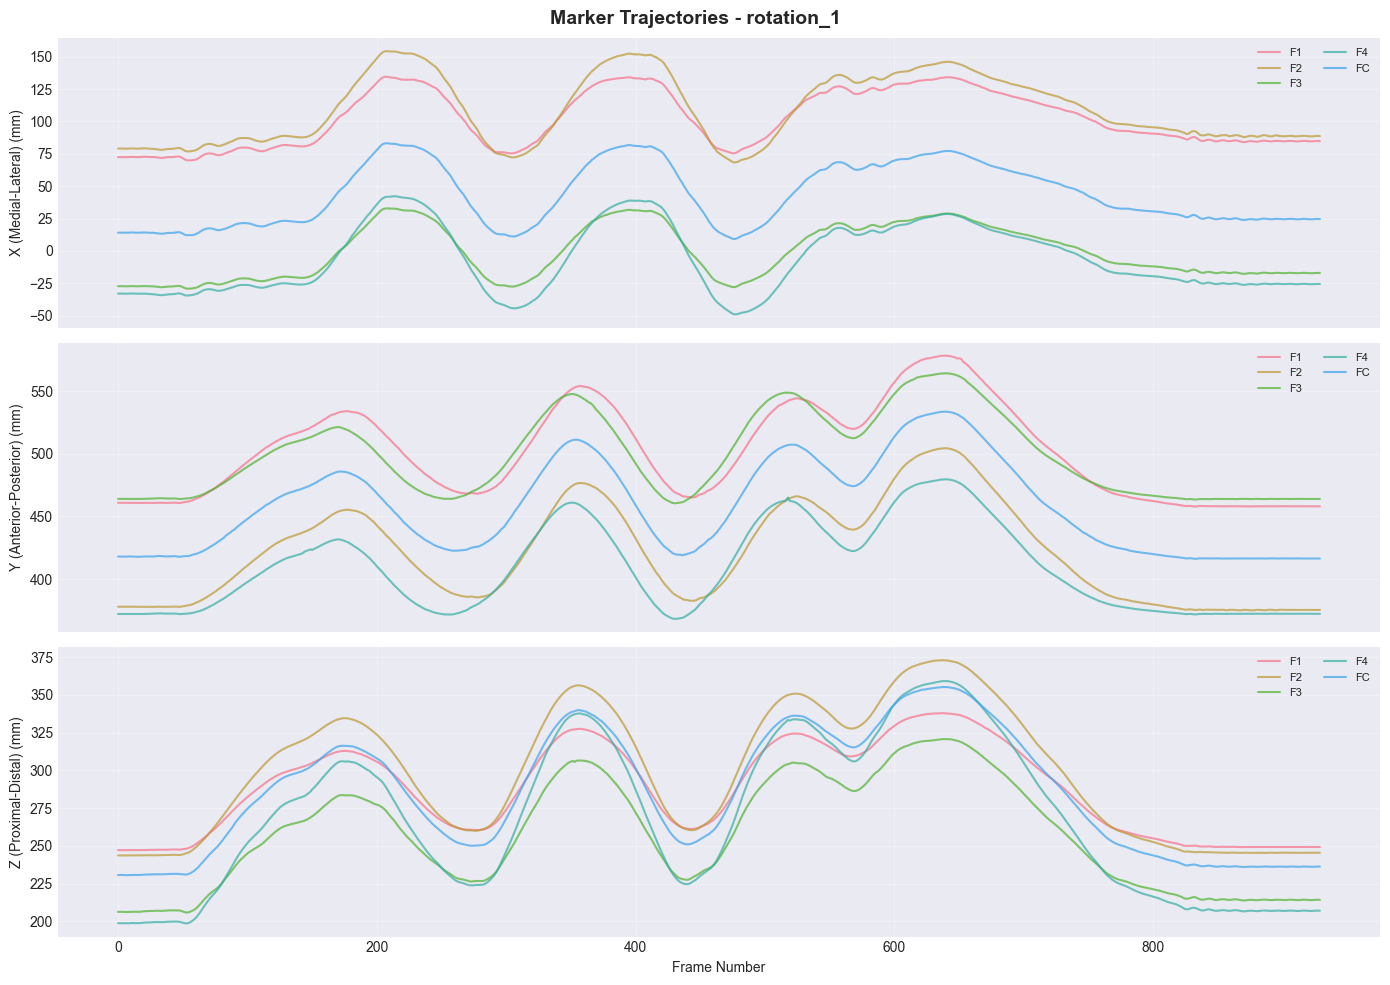


✓ Dynamic trial visualization complete


In [15]:
def plot_marker_trajectories(trial_name, markers_dict, marker_names=None):
    """
    Plot marker trajectories over time for a specific trial.
    """
    if marker_names is None:
        marker_names = list(markers_dict.keys())
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes_labels = ['X (Medial-Lateral)', 'Y (Anterior-Posterior)', 'Z (Proximal-Distal)']
    
    for marker_name in marker_names:
        if marker_name in markers_dict:
            traj = markers_dict[marker_name]
            frames = np.arange(len(traj))
            
            for i, ax in enumerate(axes):
                ax.plot(frames, traj[:, i], label=marker_name, alpha=0.7)
    
    for i, ax in enumerate(axes):
        ax.set_ylabel(f'{axes_labels[i]} (mm)', fontsize=10)
        ax.legend(loc='upper right', fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Frame Number', fontsize=10)
    fig.suptitle(f'Marker Trajectories - {trial_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./outputs/trajectories_{trial_name}.png', 
                dpi=200, bbox_inches='tight')
    plt.show()

# Plot rotation trial trajectories
if 'rotation_1' in trials:
    plot_marker_trajectories('rotation_1', trials['rotation_1'], 
                            marker_names=['F1', 'F2', 'F3', 'F4', 'FC'])

print("\n✓ Dynamic trial visualization complete")

## 12. Output Interpretation Guide

### Key Metrics:

1. **Hip Joint Center (HJC) Precision:**
   - Target: < 10 mm
   - Your result: Based on Pivot method validation

2. **Knee Offset from Mechanical Axis:**
   - Normal: < 20 mm
   - Indicates degree of varus/valgus deformity

3. **Varus/Valgus Angle:**
   - 180° = Perfect neutral alignment
   - 175-185° = Normal range
   - < 175° = Varus deformity (bow-legged)
   - > 185° = Valgus deformity (knock-knee)

### Notes:
- AJC estimation without malleoli markers has limitations
- Consider adding ankle markers for improved accuracy
- Validate with radiographic measurements

---
## Analysis Complete!

All mechanical axis parameters have been calculated and exported.
The `./outputs/` directory should have the following:
- Summary JSON file
- Results CSV file  
- 3D visualization image
- Trajectory plots

## Animation Setup and Helper Functions

In [16]:
# Animation libraries
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

def create_skeleton_connections():
    """
    Define connections between markers to form skeleton visualization.
    Returns list of marker pairs to connect with lines.
    """
    connections = [
        # Femur markers (forming a cluster)
        ('F1', 'F2'), ('F2', 'F3'), ('F3', 'F4'), ('F4', 'F1'),  # Square cluster
        ('F1', 'FC'), ('F2', 'FC'), ('F3', 'FC'), ('F4', 'FC'),  # Spokes to center
        
        # Tibia markers (forming a cluster)
        ('T1', 'T2'), ('T2', 'T3'), ('T3', 'T4'), ('T4', 'T1'),  # Square cluster
        ('T1', 'TC'), ('T2', 'TC'), ('T3', 'TC'), ('T4', 'TC'),  # Spokes to center
    ]
    return connections

def calculate_frame_hjc(femur_markers, frame_idx, reference_hjc):
    """
    Calculate instantaneous HJC for a single frame using centroid method.
    In practice, HJC is fixed, but this shows the estimation process.
    """
    # Get all femur marker positions at this frame
    positions = []
    for marker_name in ['F1', 'F2', 'F3', 'F4', 'FC']:
        if marker_name in femur_markers:
            pos = femur_markers[marker_name][frame_idx]
            if not np.isnan(pos).any():
                positions.append(pos)
    
    if len(positions) >= 3:
        # Estimate as centroid of femur cluster (simplified)
        centroid = np.mean(positions, axis=0)
        # Offset from centroid to approximate HJC location
        offset = reference_hjc - np.mean([femur_markers[m][0] for m in ['F1', 'F2', 'F3', 'F4', 'FC'] if m in femur_markers], axis=0)
        return centroid + offset
    else:
        return reference_hjc

def calculate_frame_kjc(femur_markers, frame_idx, reference_kjc):
    """
    Calculate instantaneous KJC for a single frame.
    Uses mean position of femur markers as proxy.
    """
    positions = []
    for marker_name in ['F1', 'F2', 'F3', 'F4']:
        if marker_name in femur_markers:
            pos = femur_markers[marker_name][frame_idx]
            if not np.isnan(pos).any():
                positions.append(pos)
    
    if len(positions) >= 2:
        return np.mean(positions, axis=0)
    else:
        return reference_kjc

print("Animation helper functions loaded successfully!")

Animation helper functions loaded successfully!


## Hip Rotation Animation for HJC

In [18]:
def animate_hip_rotation_hjc(trial_markers, hjc, kjc, trial_name='rotation_1', 
                             frame_step=2, duration=10):
    """
    Animate hip rotation trial showing femoral markers rotating around HJC.
    Demonstrates the Pivot method validation.
    
    Args:
        trial_markers: Dictionary of marker trajectories
        hjc: Hip joint center (reference)
        kjc: Knee joint center (reference)
        trial_name: Name for saving file
        frame_step: Use every Nth frame (for speed)
        duration: Animation duration in seconds
    """
    # Get valid frames (no NaN in key markers)
    femur_marker_names = ['F1', 'F2', 'F3', 'F4', 'FC']
    valid_frames = []
    
    for i in range(len(trial_markers['F1'])):
        if all(not np.isnan(trial_markers[m][i]).any() 
               for m in femur_marker_names if m in trial_markers):
            valid_frames.append(i)
    
    # Subsample frames
    frames_to_plot = valid_frames[::frame_step]
    n_frames = len(frames_to_plot)
    
    print(f"Animating {n_frames} frames from {trial_name}...")
    
    # Setup figure
    fig = plt.figure(figsize=(16, 6))
    
    # 3D view
    ax1 = fig.add_subplot(131, projection='3d')
    # Top view (X-Y plane)
    ax2 = fig.add_subplot(132)
    # Side view (Y-Z plane)
    ax3 = fig.add_subplot(133)
    
    # Calculate bounds
    all_positions = np.vstack([trial_markers[m][valid_frames] 
                               for m in femur_marker_names if m in trial_markers])
    x_range = [all_positions[:, 0].min() - 50, all_positions[:, 0].max() + 50]
    y_range = [all_positions[:, 1].min() - 50, all_positions[:, 1].max() + 50]
    z_range = [all_positions[:, 2].min() - 50, all_positions[:, 2].max() + 50]
    
    def init():
        """Initialize animation"""
        ax1.clear()
        ax2.clear()
        ax3.clear()
        return []
    
    def animate(frame_num):
        """Update animation for each frame"""
        ax1.clear()
        ax2.clear()
        ax3.clear()
        
        frame_idx = frames_to_plot[frame_num]
        
        # Get marker positions at this frame
        marker_pos = {}
        for marker in femur_marker_names:
            if marker in trial_markers:
                marker_pos[marker] = trial_markers[marker][frame_idx]
        
        # Calculate instantaneous joint centers
        frame_hjc = calculate_frame_hjc(trial_markers, frame_idx, hjc)
        frame_kjc = calculate_frame_kjc(trial_markers, frame_idx, kjc)
        
        # Plot markers and connections in 3D
        for marker, pos in marker_pos.items():
            ax1.scatter(*pos, s=100, alpha=0.8, label=marker)
        
        # Draw skeleton connections
        connections = create_skeleton_connections()
        for m1, m2 in connections:
            if m1 in marker_pos and m2 in marker_pos:
                points = np.array([marker_pos[m1], marker_pos[m2]])
                ax1.plot(points[:, 0], points[:, 1], points[:, 2], 
                        'gray', alpha=0.5, linewidth=1)
        
        # Plot HJC and connection
        ax1.scatter(*frame_hjc, s=200, c='red', marker='*', 
                   label='HJC', zorder=10, edgecolors='black', linewidth=2)
        ax1.scatter(*frame_kjc, s=150, c='blue', marker='o', 
                   label='KJC', zorder=10, edgecolors='black', linewidth=2)
        
        # Draw femur line
        ax1.plot([frame_hjc[0], frame_kjc[0]], 
                [frame_hjc[1], frame_kjc[1]], 
                [frame_hjc[2], frame_kjc[2]], 
                'b-', linewidth=3, alpha=0.7, label='Femur')
        
        # Draw radius lines from HJC to each femur marker
        for marker, pos in marker_pos.items():
            ax1.plot([frame_hjc[0], pos[0]], 
                    [frame_hjc[1], pos[1]], 
                    [frame_hjc[2], pos[2]], 
                    'r--', alpha=0.3, linewidth=1)
        
        # Set 3D view properties
        ax1.set_xlim(x_range)
        ax1.set_ylim(y_range)
        ax1.set_zlim(z_range)
        ax1.set_xlabel('X (mm)')
        ax1.set_ylabel('Y (mm)')
        ax1.set_zlabel('Z (mm)')
        ax1.set_title(f'3D View - Frame {frame_idx}', fontweight='bold')
        ax1.legend(loc='upper right', fontsize=8)
        ax1.view_init(elev=20, azim=45)
        
        # Top view (X-Y plane) - shows circular motion
        ax2.scatter(frame_hjc[0], frame_hjc[1], s=200, c='red', 
                   marker='*', zorder=10, label='HJC')
        for marker, pos in marker_pos.items():
            ax2.scatter(pos[0], pos[1], s=100, alpha=0.8, label=marker)
            # Draw radius line
            ax2.plot([frame_hjc[0], pos[0]], [frame_hjc[1], pos[1]], 
                    'r--', alpha=0.3, linewidth=1)
        
        # Draw trajectory trails
        for marker in femur_marker_names:
            if marker in trial_markers:
                trail = trial_markers[marker][valid_frames[:frame_num+1]]
                ax2.plot(trail[:, 0], trail[:, 1], alpha=0.3, linewidth=1)
        
        ax2.set_xlim(x_range)
        ax2.set_ylim(y_range)
        ax2.set_xlabel('X - Medial/Lateral (mm)')
        ax2.set_ylabel('Y - Anterior/Posterior (mm)')
        ax2.set_title('Top View - Circular Motion', fontweight='bold')
        ax2.legend(loc='upper right', fontsize=8)
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')
        
        # Side view (Y-Z plane)
        ax3.scatter(frame_hjc[1], frame_hjc[2], s=200, c='red', 
                   marker='*', zorder=10, label='HJC')
        for marker, pos in marker_pos.items():
            ax3.scatter(pos[1], pos[2], s=100, alpha=0.8, label=marker)
        
        ax3.set_xlim(y_range)
        ax3.set_ylim(z_range)
        ax3.set_xlabel('Y - Anterior/Posterior (mm)')
        ax3.set_ylabel('Z - Proximal/Distal (mm)')
        ax3.set_title('Side View', fontweight='bold')
        ax3.legend(loc='upper right', fontsize=8)
        ax3.grid(True, alpha=0.3)
        ax3.set_aspect('equal')
        
        fig.suptitle(f'Hip Rotation - HJC Validation ({trial_name})\nFrame {frame_idx}/{valid_frames[-1]}', 
                    fontsize=14, fontweight='bold')
        
        return []
    
    # Create animation
    anim = FuncAnimation(fig, animate, init_func=init, frames=n_frames,
                        interval=duration*1000/n_frames, blit=True)
    
    # Save as GIF
    output_path = f'./outputs/hip_rotation_hjc_{trial_name}.gif'
    print(f"Saving animation to {output_path}...")
    writer = PillowWriter(fps=n_frames/duration)
    anim.save(output_path, writer=writer, dpi=100)
    print(f"✓ Animation saved successfully!")
    
    plt.close()
    
    return anim

# Animate rotation trial 1
if 'rotation_1' in trials:
    anim1 = animate_hip_rotation_hjc(trials['rotation_1'], hjc, kjc, 
                                      trial_name='rotation_1', frame_step=3, duration=8)
    print("\n✓ Hip rotation animation created for rotation_1")

Animating 310 frames from rotation_1...
Saving animation to ./outputs/hip_rotation_hjc_rotation_1.gif...
✓ Animation saved successfully!

✓ Hip rotation animation created for rotation_1


## Mech-Axis Computation

In [19]:
def animate_mechanical_axis_computation(trial_markers, hjc, kjc, ajc, R_femur,
                                       trial_name='rotation_1', frame_step=3, duration=10):
    """
    Animate the mechanical axis computation in real-time as markers move.
    Shows how the axis would be calculated if we were doing intra-operative navigation.
    """
    # Get all marker names
    all_markers = ['F1', 'F2', 'F3', 'F4', 'FC', 'T1', 'T2', 'T3', 'T4', 'TC']
    
    # Find valid frames
    valid_frames = []
    for i in range(len(trial_markers['F1'])):
        if all(not np.isnan(trial_markers.get(m, [[np.nan]])[i]).any() 
               for m in ['F1', 'F2', 'F3', 'F4', 'T1', 'T2']):
            valid_frames.append(i)
    
    frames_to_plot = valid_frames[::frame_step]
    n_frames = len(frames_to_plot)
    
    print(f"Animating mechanical axis computation for {n_frames} frames...")
    
    fig = plt.figure(figsize=(18, 6))
    
    # 3D full skeleton
    ax1 = fig.add_subplot(131, projection='3d')
    # Frontal plane with mechanical axis
    ax2 = fig.add_subplot(132)
    # Metrics over time
    ax3 = fig.add_subplot(133)
    
    # Storage for metrics over time
    knee_offsets = []
    vv_angles = []
    frame_numbers = []
    
    def init():
        ax1.clear()
        ax2.clear()
        ax3.clear()
        return []
    
    def animate(frame_num):
        ax1.clear()
        ax2.clear()
        ax3.clear()
        
        frame_idx = frames_to_plot[frame_num]
        
        # Get all marker positions
        marker_pos = {}
        for marker in all_markers:
            if marker in trial_markers:
                pos = trial_markers[marker][frame_idx]
                if not np.isnan(pos).any():
                    marker_pos[marker] = pos
        
        # Calculate joint centers for this frame
        frame_hjc = calculate_frame_hjc(trial_markers, frame_idx, hjc)
        frame_kjc = calculate_frame_kjc(trial_markers, frame_idx, kjc)
        
        # Estimate AJC from tibia markers
        tibia_positions = [marker_pos[m] for m in ['T1', 'T2', 'T3', 'T4', 'TC'] 
                          if m in marker_pos]
        if tibia_positions:
            tibia_centroid = np.mean(tibia_positions, axis=0)
            tibia_axis = frame_kjc - tibia_centroid
            tibia_axis_norm = tibia_axis / np.linalg.norm(tibia_axis)
            frame_ajc = tibia_centroid - tibia_axis_norm * 200  # Approximate
        else:
            frame_ajc = ajc
        
        # Calculate mechanical axis for this frame
        mech_axis_vec = frame_ajc - frame_hjc
        mech_axis_length = np.linalg.norm(mech_axis_vec)
        
        # Calculate knee offset
        hjc_to_kjc = frame_kjc - frame_hjc
        projection_length = np.dot(hjc_to_kjc, mech_axis_vec) / mech_axis_length
        projection_point = frame_hjc + (projection_length / mech_axis_length) * mech_axis_vec
        knee_offset_vec = frame_kjc - projection_point
        knee_offset = np.linalg.norm(knee_offset_vec)
        
        # Calculate varus/valgus angle (simplified)
        femur_vec = frame_hjc - frame_kjc
        tibia_vec = frame_ajc - frame_kjc
        cos_angle = np.dot(femur_vec, tibia_vec) / (np.linalg.norm(femur_vec) * np.linalg.norm(tibia_vec))
        angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
        vv_angle = 180 - angle
        
        # Store metrics
        knee_offsets.append(knee_offset)
        vv_angles.append(vv_angle)
        frame_numbers.append(frame_idx)
        
        # ===== 3D PLOT =====
        # Plot markers
        femur_colors = plt.cm.Blues(np.linspace(0.4, 0.8, 5))
        tibia_colors = plt.cm.Greens(np.linspace(0.4, 0.8, 5))
        
        for i, marker in enumerate(['F1', 'F2', 'F3', 'F4', 'FC']):
            if marker in marker_pos:
                ax1.scatter(*marker_pos[marker], s=100, c=[femur_colors[i]], 
                           alpha=0.8, edgecolors='black', linewidth=1)
        
        for i, marker in enumerate(['T1', 'T2', 'T3', 'T4', 'TC']):
            if marker in marker_pos:
                ax1.scatter(*marker_pos[marker], s=100, c=[tibia_colors[i]], 
                           alpha=0.8, edgecolors='black', linewidth=1)
        
        # Draw skeleton connections
        connections = create_skeleton_connections()
        for m1, m2 in connections:
            if m1 in marker_pos and m2 in marker_pos:
                points = np.array([marker_pos[m1], marker_pos[m2]])
                ax1.plot(points[:, 0], points[:, 1], points[:, 2], 
                        'gray', alpha=0.4, linewidth=2)
        
        # Plot joint centers
        ax1.scatter(*frame_hjc, s=250, c='red', marker='*', 
                   label='HJC', zorder=10, edgecolors='darkred', linewidth=2)
        ax1.scatter(*frame_kjc, s=200, c='blue', marker='o', 
                   label='KJC', zorder=10, edgecolors='darkblue', linewidth=2)
        ax1.scatter(*frame_ajc, s=200, c='green', marker='o', 
                   label='AJC', zorder=10, edgecolors='darkgreen', linewidth=2)
        
        # Draw bone segments
        ax1.plot([frame_hjc[0], frame_kjc[0]], [frame_hjc[1], frame_kjc[1]], 
                [frame_hjc[2], frame_kjc[2]], 'b-', linewidth=4, alpha=0.7, label='Femur')
        ax1.plot([frame_kjc[0], frame_ajc[0]], [frame_kjc[1], frame_ajc[1]], 
                [frame_kjc[2], frame_ajc[2]], 'g-', linewidth=4, alpha=0.7, label='Tibia')
        
        # Draw mechanical axis
        ax1.plot([frame_hjc[0], frame_ajc[0]], [frame_hjc[1], frame_ajc[1]], 
                [frame_hjc[2], frame_ajc[2]], 'r--', linewidth=3, alpha=0.9, 
                label='Mechanical Axis')
        
        # Draw knee offset
        ax1.plot([frame_kjc[0], projection_point[0]], 
                [frame_kjc[1], projection_point[1]], 
                [frame_kjc[2], projection_point[2]], 
                'orange', linewidth=2, alpha=0.8, label=f'Offset: {knee_offset:.1f}mm')
        
        ax1.set_xlabel('X (mm)', fontsize=10)
        ax1.set_ylabel('Y (mm)', fontsize=10)
        ax1.set_zlabel('Z (mm)', fontsize=10)
        ax1.set_title('3D Skeleton & Mechanical Axis', fontweight='bold')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.view_init(elev=15, azim=45)
        
        # ===== FRONTAL PLANE =====
        # Project to frontal plane
        def project_to_frontal(point):
            x = np.dot(point - frame_kjc, R_femur[:, 0])
            y = np.dot(point - frame_kjc, R_femur[:, 1])
            return x, y
        
        hjc_2d = project_to_frontal(frame_hjc)
        kjc_2d = (0, 0)
        ajc_2d = project_to_frontal(frame_ajc)
        
        # Plot bones
        ax2.plot([hjc_2d[0], kjc_2d[0]], [hjc_2d[1], kjc_2d[1]], 
                'b-', linewidth=6, label='Femur', alpha=0.7)
        ax2.plot([kjc_2d[0], ajc_2d[0]], [kjc_2d[1], ajc_2d[1]], 
                'g-', linewidth=6, label='Tibia', alpha=0.7)
        
        # Plot mechanical axis
        ax2.plot([hjc_2d[0], ajc_2d[0]], [hjc_2d[1], ajc_2d[1]], 
                'r--', linewidth=3, label='Mechanical Axis', alpha=0.9)
        
        # Plot joint centers
        ax2.scatter(*hjc_2d, s=200, c='red', marker='*', zorder=10, 
                   edgecolors='darkred', linewidth=2)
        ax2.scatter(*kjc_2d, s=150, c='blue', marker='o', zorder=10,
                   edgecolors='darkblue', linewidth=2)
        ax2.scatter(*ajc_2d, s=150, c='green', marker='o', zorder=10,
                   edgecolors='darkgreen', linewidth=2)
        
        # Add annotations
        ax2.text(0.05, 0.95, f'Knee Offset: {knee_offset:.1f} mm', 
                transform=ax2.transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        ax2.text(0.05, 0.88, f'VV Angle: {vv_angle:.1f}°', 
                transform=ax2.transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
        
        ax2.set_xlabel('Medial-Lateral (mm)', fontsize=10)
        ax2.set_ylabel('Proximal-Distal (mm)', fontsize=10)
        ax2.set_title('Frontal Plane - Alignment', fontweight='bold')
        ax2.legend(loc='lower right', fontsize=8)
        ax2.grid(True, alpha=0.3)
        ax2.axis('equal')
        
        # ===== METRICS OVER TIME =====
        if len(frame_numbers) > 1:
            ax3_twin = ax3.twinx()
            
            # Plot knee offset
            ax3.plot(frame_numbers, knee_offsets, 'o-', color='orange', 
                    linewidth=2, markersize=6, label='Knee Offset')
            ax3.axhline(y=20, color='red', linestyle='--', alpha=0.5, 
                       label='Normal Threshold (20mm)')
            ax3.set_ylabel('Knee Offset (mm)', fontsize=10, color='orange')
            ax3.tick_params(axis='y', labelcolor='orange')
            
            # Plot VV angle
            ax3_twin.plot(frame_numbers, vv_angles, 's-', color='blue', 
                         linewidth=2, markersize=6, label='VV Angle')
            ax3_twin.axhline(y=180, color='green', linestyle='--', alpha=0.5,
                            label='Neutral (180°)')
            ax3_twin.set_ylabel('Varus/Valgus Angle (°)', fontsize=10, color='blue')
            ax3_twin.tick_params(axis='y', labelcolor='blue')
            
            ax3.set_xlabel('Frame Number', fontsize=10)
            ax3.set_title('Real-Time Metrics Evolution', fontweight='bold')
            ax3.grid(True, alpha=0.3)
            
            # Combine legends
            lines1, labels1 = ax3.get_legend_handles_labels()
            lines2, labels2 = ax3_twin.get_legend_handles_labels()
            ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
        
        fig.suptitle(f'Real-Time Mechanical Axis Computation - {trial_name}\nFrame {frame_idx}', 
                    fontsize=14, fontweight='bold')
        
        return []
    
    # Create animation
    anim = FuncAnimation(fig, animate, init_func=init, frames=n_frames,
                        interval=duration*1000/n_frames, blit=True)
    
    # Save
    output_path = f'./outputs/mechanical_axis_realtime_{trial_name}.gif'
    print(f"Saving animation to {output_path}...")
    writer = PillowWriter(fps=max(10, n_frames/duration))
    anim.save(output_path, writer=writer, dpi=100)
    print(f"✓ Real-time mechanical axis animation saved!")
    
    plt.close()
    
    return anim

# Animate mechanical axis computation
if 'rotation_1' in trials:
    anim2 = animate_mechanical_axis_computation(trials['rotation_1'], hjc, kjc, ajc, R_femur,
                                                trial_name='rotation_1', frame_step=4, duration=10)
    print("\n✓ Mechanical axis computation animation created")

Animating mechanical axis computation for 233 frames...
Saving animation to ./outputs/mechanical_axis_realtime_rotation_1.gif...
✓ Real-time mechanical axis animation saved!

✓ Mechanical axis computation animation created


## Marker Cluster Rigidity Visualization

In [21]:
def visualize_marker_cluster_rigidity(trial_markers, trial_name='rotation_1', 
                                     frame_step=3, duration=10):
    """
    Visualize how rigidly the marker clusters move together.
    Shows inter-marker distances to validate rigid body assumption.
    """
    femur_markers = ['F1', 'F2', 'F3', 'F4', 'FC']
    tibia_markers = ['T1', 'T2', 'T3', 'T4', 'TC']
    
    # Find valid frames
    valid_frames = []
    for i in range(len(trial_markers['F1'])):
        if all(not np.isnan(trial_markers.get(m, [[np.nan]])[i]).any() 
               for m in femur_markers + tibia_markers if m in trial_markers):
            valid_frames.append(i)
    
    frames_to_plot = valid_frames[::frame_step]
    n_frames = len(frames_to_plot)
    
    print(f"Analyzing marker cluster rigidity for {n_frames} frames...")
    
    # Calculate inter-marker distances over time
    femur_distances = {}
    tibia_distances = {}
    
    # Define marker pairs to track
    femur_pairs = [('F1', 'F2'), ('F2', 'F3'), ('F3', 'F4'), ('F4', 'F1'), 
                   ('F1', 'FC'), ('F3', 'FC')]
    tibia_pairs = [('T1', 'T2'), ('T2', 'T3'), ('T3', 'T4'), ('T4', 'T1'), 
                   ('T1', 'TC'), ('T3', 'TC')]
    
    # Calculate distances for all frames
    for pair in femur_pairs:
        distances = []
        for frame_idx in valid_frames:
            if pair[0] in trial_markers and pair[1] in trial_markers:
                pos1 = trial_markers[pair[0]][frame_idx]
                pos2 = trial_markers[pair[1]][frame_idx]
                if not (np.isnan(pos1).any() or np.isnan(pos2).any()):
                    dist = np.linalg.norm(pos1 - pos2)
                    distances.append(dist)
                else:
                    distances.append(np.nan)
        femur_distances[f"{pair[0]}-{pair[1]}"] = distances
    
    for pair in tibia_pairs:
        distances = []
        for frame_idx in valid_frames:
            if pair[0] in trial_markers and pair[1] in trial_markers:
                pos1 = trial_markers[pair[0]][frame_idx]
                pos2 = trial_markers[pair[1]][frame_idx]
                if not (np.isnan(pos1).any() or np.isnan(pos2).any()):
                    dist = np.linalg.norm(pos1 - pos2)
                    distances.append(dist)
                else:
                    distances.append(np.nan)
        tibia_distances[f"{pair[0]}-{pair[1]}"] = distances
    
    # Create animation
    fig = plt.figure(figsize=(18, 10))
    
    # 3D cluster visualization
    ax1 = fig.add_subplot(231, projection='3d')
    ax2 = fig.add_subplot(232, projection='3d')
    
    # Distance variation plots
    ax3 = fig.add_subplot(233)
    ax4 = fig.add_subplot(234)
    
    # Distance statistics
    ax5 = fig.add_subplot(235)
    ax6 = fig.add_subplot(236)
    
    def init():
        for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
            ax.clear()
        return []
    
    def animate(frame_num):
        for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
            ax.clear()
        
        frame_idx = frames_to_plot[frame_num]
        actual_frame_in_valid = valid_frames.index(frame_idx)
        
        # Get marker positions
        femur_pos = {m: trial_markers[m][frame_idx] for m in femur_markers 
                     if m in trial_markers}
        tibia_pos = {m: trial_markers[m][frame_idx] for m in tibia_markers 
                     if m in trial_markers}
        
        # ===== FEMUR CLUSTER 3D =====
        colors_f = plt.cm.Blues(np.linspace(0.4, 0.9, len(femur_pos)))
        for i, (marker, pos) in enumerate(femur_pos.items()):
            ax1.scatter(*pos, s=150, c=[colors_f[i]], alpha=0.8, 
                       label=marker, edgecolors='black', linewidth=2)
        
        # Draw connections
        for pair in femur_pairs:
            if pair[0] in femur_pos and pair[1] in femur_pos:
                points = np.array([femur_pos[pair[0]], femur_pos[pair[1]]])
                dist = np.linalg.norm(points[1] - points[0])
                ax1.plot(points[:, 0], points[:, 1], points[:, 2], 
                        'b-', linewidth=3, alpha=0.6)
                # Label distance
                mid = (points[0] + points[1]) / 2
                ax1.text(mid[0], mid[1], mid[2], f'{dist:.1f}', fontsize=8)
        
        ax1.set_xlabel('X (mm)')
        ax1.set_ylabel('Y (mm)')
        ax1.set_zlabel('Z (mm)')
        ax1.set_title('Femur Marker Cluster', fontweight='bold')
        ax1.legend(loc='upper right', fontsize=8)
        ax1.view_init(elev=20, azim=45)
        
        # ===== TIBIA CLUSTER 3D =====
        colors_t = plt.cm.Greens(np.linspace(0.4, 0.9, len(tibia_pos)))
        for i, (marker, pos) in enumerate(tibia_pos.items()):
            ax2.scatter(*pos, s=150, c=[colors_t[i]], alpha=0.8, 
                       label=marker, edgecolors='black', linewidth=2)
        
        # Draw connections
        for pair in tibia_pairs:
            if pair[0] in tibia_pos and pair[1] in tibia_pos:
                points = np.array([tibia_pos[pair[0]], tibia_pos[pair[1]]])
                dist = np.linalg.norm(points[1] - points[0])
                ax2.plot(points[:, 0], points[:, 1], points[:, 2], 
                        'g-', linewidth=3, alpha=0.6)
                # Label distance
                mid = (points[0] + points[1]) / 2
                ax2.text(mid[0], mid[1], mid[2], f'{dist:.1f}', fontsize=8)
        
        ax2.set_xlabel('X (mm)')
        ax2.set_ylabel('Y (mm)')
        ax2.set_zlabel('Z (mm)')
        ax2.set_title('Tibia Marker Cluster', fontweight='bold')
        ax2.legend(loc='upper right', fontsize=8)
        ax2.view_init(elev=20, azim=-45)
        
        # ===== FEMUR DISTANCE VARIATION =====
        for pair_name, distances in femur_distances.items():
            distances_so_far = distances[:actual_frame_in_valid+1]
            frames_so_far = valid_frames[:actual_frame_in_valid+1]
            ax3.plot(frames_so_far, distances_so_far, 'o-', 
                    label=pair_name, alpha=0.7, markersize=4)
        
        ax3.set_xlabel('Frame Number')
        ax3.set_ylabel('Inter-Marker Distance (mm)')
        ax3.set_title('Femur Cluster - Distance Stability', fontweight='bold')
        ax3.legend(loc='upper right', fontsize=7)
        ax3.grid(True, alpha=0.3)
        
        # ===== TIBIA DISTANCE VARIATION =====
        for pair_name, distances in tibia_distances.items():
            distances_so_far = distances[:actual_frame_in_valid+1]
            frames_so_far = valid_frames[:actual_frame_in_valid+1]
            ax4.plot(frames_so_far, distances_so_far, 's-', 
                    label=pair_name, alpha=0.7, markersize=4)
        
        ax4.set_xlabel('Frame Number')
        ax4.set_ylabel('Inter-Marker Distance (mm)')
        ax4.set_title('Tibia Cluster - Distance Stability', fontweight='bold')
        ax4.legend(loc='upper right', fontsize=7)
        ax4.grid(True, alpha=0.3)
        
        # ===== FEMUR STATISTICS =====
        stats_f = []
        for pair_name, distances in femur_distances.items():
            valid_dist = [d for d in distances[:actual_frame_in_valid+1] if not np.isnan(d)]
            if valid_dist:
                mean_dist = np.mean(valid_dist)
                std_dist = np.std(valid_dist)
                cv = (std_dist / mean_dist) * 100  # Coefficient of variation
                stats_f.append((pair_name, mean_dist, std_dist, cv))
        
        if stats_f:
            pair_names = [s[0] for s in stats_f]
            cvs = [s[3] for s in stats_f]
            
            bars = ax5.barh(pair_names, cvs, color='steelblue', alpha=0.7)
            ax5.axvline(x=1.0, color='green', linestyle='--', linewidth=2, 
                       label='Excellent (<1%)')
            ax5.axvline(x=2.0, color='orange', linestyle='--', linewidth=2, 
                       label='Good (<2%)')
            ax5.set_xlabel('Coefficient of Variation (%)')
            ax5.set_title('Femur Rigidity\n(Lower = More Rigid)', fontweight='bold')
            ax5.legend(loc='lower right', fontsize=7)
            ax5.grid(True, alpha=0.3, axis='x')
            
            # Color code bars
            for bar, cv in zip(bars, cvs):
                if cv < 1.0:
                    bar.set_color('green')
                elif cv < 2.0:
                    bar.set_color('orange')
                else:
                    bar.set_color('red')
        
        # ===== TIBIA STATISTICS =====
        stats_t = []
        for pair_name, distances in tibia_distances.items():
            valid_dist = [d for d in distances[:actual_frame_in_valid+1] if not np.isnan(d)]
            if valid_dist:
                mean_dist = np.mean(valid_dist)
                std_dist = np.std(valid_dist)
                cv = (std_dist / mean_dist) * 100
                stats_t.append((pair_name, mean_dist, std_dist, cv))
        
        if stats_t:
            pair_names = [s[0] for s in stats_t]
            cvs = [s[3] for s in stats_t]
            
            bars = ax6.barh(pair_names, cvs, color='forestgreen', alpha=0.7)
            ax6.axvline(x=1.0, color='green', linestyle='--', linewidth=2, 
                       label='Excellent (<1%)')
            ax6.axvline(x=2.0, color='orange', linestyle='--', linewidth=2, 
                       label='Good (<2%)')
            ax6.set_xlabel('Coefficient of Variation (%)')
            ax6.set_title('Tibia Rigidity\n(Lower = More Rigid)', fontweight='bold')
            ax6.legend(loc='lower right', fontsize=7)
            ax6.grid(True, alpha=0.3, axis='x')
            
            # Color code bars
            for bar, cv in zip(bars, cvs):
                if cv < 1.0:
                    bar.set_color('green')
                elif cv < 2.0:
                    bar.set_color('orange')
                else:
                    bar.set_color('red')
        
        fig.suptitle(f'Marker Cluster Rigidity Analysis - {trial_name}\nFrame {frame_idx}', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        return []
    
    # Create animation
    anim = FuncAnimation(fig, animate, init_func=init, frames=n_frames,
                        interval=duration*1000/n_frames, blit=True)
    
    # Save
    output_path = f'./outputs/cluster_rigidity_{trial_name}.gif'
    print(f"Saving rigidity analysis to {output_path}...")
    writer = PillowWriter(fps=max(8, n_frames/duration))
    anim.save(output_path, writer=writer, dpi=100)
    print(f"✓ Cluster rigidity animation saved!")
    
    plt.close()
    
    return anim

# Visualize cluster rigidity
if 'rotation_1' in trials:
    anim3 = visualize_marker_cluster_rigidity(trials['rotation_1'], 
                                             trial_name='rotation_1', 
                                             frame_step=4, duration=10)
    print("\n✓ Marker cluster rigidity visualization created")

Analyzing marker cluster rigidity for 233 frames...
Saving rigidity analysis to ./outputs/cluster_rigidity_rotation_1.gif...
✓ Cluster rigidity animation saved!

✓ Marker cluster rigidity visualization created


## Complete MOCAP Pipeline Visualisation

In [20]:
def illustrate_complete_pipeline(trial_markers, hjc, kjc, ajc, R_femur, 
                                anatomical_landmarks, trial_name='rotation_1',
                                frame_step=5, duration=12):
    """
    Comprehensive visualization showing the entire NNK System pipeline:
    1. Raw marker capture
    2. Joint center estimation
    3. Anatomical frame establishment
    4. Mechanical axis computation
    5. Clinical metrics output
    """
    all_markers = ['F1', 'F2', 'F3', 'F4', 'FC', 'T1', 'T2', 'T3', 'T4', 'TC']
    
    # Find valid frames
    valid_frames = []
    for i in range(len(trial_markers['F1'])):
        if all(not np.isnan(trial_markers.get(m, [[np.nan]])[i]).any() 
               for m in ['F1', 'F2', 'T1', 'T2'] if m in trial_markers):
            valid_frames.append(i)
    
    frames_to_plot = valid_frames[::frame_step]
    n_frames = len(frames_to_plot)
    
    print(f"Creating complete pipeline visualization with {n_frames} frames...")
    
    fig = plt.figure(figsize=(20, 12))
    
    # Create 6 subplots showing pipeline stages
    ax1 = fig.add_subplot(3, 3, 1, projection='3d')  # Raw markers
    ax2 = fig.add_subplot(3, 3, 2, projection='3d')  # + Joint centers
    ax3 = fig.add_subplot(3, 3, 3, projection='3d')  # + Anatomical frames
    ax4 = fig.add_subplot(3, 3, 4)                   # Frontal view
    ax5 = fig.add_subplot(3, 3, 5)                   # Metrics dashboard
    ax6 = fig.add_subplot(3, 3, 6)                   # Pipeline flowchart
    ax7 = fig.add_subplot(3, 3, 7, projection='3d')  # Final full model
    ax8 = fig.add_subplot(3, 3, 8)                   # Time series
    ax9 = fig.add_subplot(3, 3, 9)                   # Clinical summary
    
    # Storage for time series
    all_knee_offsets = []
    all_vv_angles = []
    all_frame_nums = []
    
    def init():
        for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]:
            if hasattr(ax, 'clear'):
                ax.clear()
        return []
    
    def animate(frame_num):
        for ax in [ax1, ax2, ax3, ax4, ax5, ax7, ax8, ax9]:
            if hasattr(ax, 'clear'):
                ax.clear()
        
        frame_idx = frames_to_plot[frame_num]
        
        # Get marker positions
        marker_pos = {}
        for marker in all_markers:
            if marker in trial_markers:
                pos = trial_markers[marker][frame_idx]
                if not np.isnan(pos).any():
                    marker_pos[marker] = pos
        
        # Calculate frame-specific joint centers
        frame_hjc = calculate_frame_hjc(trial_markers, frame_idx, hjc)
        frame_kjc = calculate_frame_kjc(trial_markers, frame_idx, kjc)
        
        tibia_positions = [marker_pos[m] for m in ['T1', 'T2', 'T3', 'T4', 'TC'] 
                          if m in marker_pos]
        if tibia_positions:
            tibia_centroid = np.mean(tibia_positions, axis=0)
            tibia_axis = frame_kjc - tibia_centroid
            tibia_axis_norm = tibia_axis / np.linalg.norm(tibia_axis)
            frame_ajc = tibia_centroid - tibia_axis_norm * 200
        else:
            frame_ajc = ajc
        
        # Calculate metrics
        mech_axis_vec = frame_ajc - frame_hjc
        mech_axis_length = np.linalg.norm(mech_axis_vec)
        hjc_to_kjc = frame_kjc - frame_hjc
        projection_length = np.dot(hjc_to_kjc, mech_axis_vec) / mech_axis_length
        projection_point = frame_hjc + (projection_length / mech_axis_length) * mech_axis_vec
        knee_offset = np.linalg.norm(frame_kjc - projection_point)
        
        femur_vec = frame_hjc - frame_kjc
        tibia_vec = frame_ajc - frame_kjc
        cos_angle = np.dot(femur_vec, tibia_vec) / (np.linalg.norm(femur_vec) * np.linalg.norm(tibia_vec))
        angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
        vv_angle = 180 - angle
        
        all_knee_offsets.append(knee_offset)
        all_vv_angles.append(vv_angle)
        all_frame_nums.append(frame_idx)
        
        # ===== STAGE 1: RAW MARKERS =====
        femur_colors = plt.cm.Blues(np.linspace(0.5, 0.9, 5))
        tibia_colors = plt.cm.Greens(np.linspace(0.5, 0.9, 5))
        
        for i, marker in enumerate(['F1', 'F2', 'F3', 'F4', 'FC']):
            if marker in marker_pos:
                ax1.scatter(*marker_pos[marker], s=120, c=[femur_colors[i]], 
                           alpha=0.9, edgecolors='black', linewidth=1.5, label=marker)
        for i, marker in enumerate(['T1', 'T2', 'T3', 'T4', 'TC']):
            if marker in marker_pos:
                ax1.scatter(*marker_pos[marker], s=120, c=[tibia_colors[i]], 
                           alpha=0.9, edgecolors='black', linewidth=1.5, label=marker)
        
        ax1.set_title('STAGE 1: Motion Capture\nRaw Marker Data', fontweight='bold', fontsize=10)
        ax1.set_xlabel('X', fontsize=8)
        ax1.set_ylabel('Y', fontsize=8)
        ax1.set_zlabel('Z', fontsize=8)
        ax1.view_init(elev=20, azim=45)
        
        # ===== STAGE 2: + JOINT CENTERS =====
        for i, marker in enumerate(['F1', 'F2', 'F3', 'F4', 'FC']):
            if marker in marker_pos:
                ax2.scatter(*marker_pos[marker], s=100, c=[femur_colors[i]], alpha=0.6)
        for i, marker in enumerate(['T1', 'T2', 'T3', 'T4', 'TC']):
            if marker in marker_pos:
                ax2.scatter(*marker_pos[marker], s=100, c=[tibia_colors[i]], alpha=0.6)
        
        ax2.scatter(*frame_hjc, s=300, c='red', marker='*', label='HJC', 
                   zorder=10, edgecolors='darkred', linewidth=2)
        ax2.scatter(*frame_kjc, s=250, c='blue', marker='o', label='KJC', 
                   zorder=10, edgecolors='darkblue', linewidth=2)
        ax2.scatter(*frame_ajc, s=250, c='green', marker='o', label='AJC', 
                   zorder=10, edgecolors='darkgreen', linewidth=2)
        
        ax2.set_title('STAGE 2: Joint Centers\nPivot Method + Landmarks', fontweight='bold', fontsize=10)
        ax2.legend(loc='upper right', fontsize=7)
        ax2.set_xlabel('X', fontsize=8)
        ax2.set_ylabel('Y', fontsize=8)
        ax2.set_zlabel('Z', fontsize=8)
        ax2.view_init(elev=20, azim=45)
        
        # ===== STAGE 3: + ANATOMICAL FRAMES =====
        for i, marker in enumerate(['F1', 'F2', 'F3', 'F4', 'FC']):
            if marker in marker_pos:
                ax3.scatter(*marker_pos[marker], s=80, c=[femur_colors[i]], alpha=0.4)
        for i, marker in enumerate(['T1', 'T2', 'T3', 'T4', 'TC']):
            if marker in marker_pos:
                ax3.scatter(*marker_pos[marker], s=80, c=[tibia_colors[i]], alpha=0.4)
        
        ax3.scatter(*frame_hjc, s=200, c='red', marker='*', zorder=10)
        ax3.scatter(*frame_kjc, s=150, c='blue', marker='o', zorder=10)
        ax3.scatter(*frame_ajc, s=150, c='green', marker='o', zorder=10)
        
        # Draw anatomical axes
        scale = 80
        colors = ['red', 'green', 'blue']
        labels = ['X(ML)', 'Y(PD)', 'Z(AP)']
        for i in range(3):
            ax3.quiver(frame_kjc[0], frame_kjc[1], frame_kjc[2],
                      R_femur[0, i]*scale, R_femur[1, i]*scale, R_femur[2, i]*scale,
                      color=colors[i], arrow_length_ratio=0.3, linewidth=2.5, alpha=0.8)
        
        ax3.set_title('STAGE 3: Anatomical Frames\nISB Coordinate Systems', fontweight='bold', fontsize=10)
        ax3.set_xlabel('X', fontsize=8)
        ax3.set_ylabel('Y', fontsize=8)
        ax3.set_zlabel('Z', fontsize=8)
        ax3.view_init(elev=20, azim=45)
        
        # ===== STAGE 4: FRONTAL PLANE =====
        def project_to_frontal(point):
            x = np.dot(point - frame_kjc, R_femur[:, 0])
            y = np.dot(point - frame_kjc, R_femur[:, 1])
            return x, y
        
        hjc_2d = project_to_frontal(frame_hjc)
        kjc_2d = (0, 0)
        ajc_2d = project_to_frontal(frame_ajc)
        
        ax4.plot([hjc_2d[0], kjc_2d[0]], [hjc_2d[1], kjc_2d[1]], 
                'b-', linewidth=8, label='Femur', alpha=0.7)
        ax4.plot([kjc_2d[0], ajc_2d[0]], [kjc_2d[1], ajc_2d[1]], 
                'g-', linewidth=8, label='Tibia', alpha=0.7)
        ax4.plot([hjc_2d[0], ajc_2d[0]], [hjc_2d[1], ajc_2d[1]], 
                'r--', linewidth=4, label='Mech Axis', alpha=0.9)
        
        ax4.scatter(*hjc_2d, s=250, c='red', marker='*', zorder=10, edgecolors='darkred', linewidth=2)
        ax4.scatter(*kjc_2d, s=200, c='blue', marker='o', zorder=10, edgecolors='darkblue', linewidth=2)
        ax4.scatter(*ajc_2d, s=200, c='green', marker='o', zorder=10, edgecolors='darkgreen', linewidth=2)
        
        ax4.set_title('STAGE 4: Mechanical Axis\nFrontal Plane Projection', fontweight='bold', fontsize=10)
        ax4.set_xlabel('Medial-Lateral (mm)', fontsize=9)
        ax4.set_ylabel('Proximal-Distal (mm)', fontsize=9)
        ax4.legend(loc='lower right', fontsize=7)
        ax4.grid(True, alpha=0.3)
        ax4.axis('equal')
        
        # ===== STAGE 5: METRICS DASHBOARD =====
        ax5.axis('off')
        
        metrics_text = f"""
REAL-TIME METRICS
{'='*30}

Joint Centers:
  HJC: [{frame_hjc[0]:.1f}, {frame_hjc[1]:.1f}, {frame_hjc[2]:.1f}]
  KJC: [{frame_kjc[0]:.1f}, {frame_kjc[1]:.1f}, {frame_kjc[2]:.1f}]
  AJC: [{frame_ajc[0]:.1f}, {frame_ajc[1]:.1f}, {frame_ajc[2]:.1f}]

Segment Lengths:
  Femur:  {np.linalg.norm(frame_hjc - frame_kjc):.1f} mm
  Tibia:  {np.linalg.norm(frame_ajc - frame_kjc):.1f} mm
  Total:  {mech_axis_length:.1f} mm

Alignment:
  Knee Offset: {knee_offset:.2f} mm
  VV Angle:    {vv_angle:.2f}°
  Deviation:   {vv_angle - 180:+.2f}°

Status:
  Offset: {'✓ Normal' if knee_offset < 20 else '⚠ Abnormal'}
  Alignment: {'✓ Neutral' if 175 < vv_angle < 185 else '⚠ Deformed'}
        """
        
        ax5.text(0.1, 0.95, metrics_text, transform=ax5.transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        ax5.set_title('STAGE 5: Clinical Metrics', fontweight='bold', fontsize=10)
        
        # ===== STAGE 6: PIPELINE FLOWCHART (STATIC) =====
        if frame_num == 0:  # Draw once
            ax6.axis('off')
            
            flowchart_text = """
    NNK SYSTEM PIPELINE
    ═══════════════════
    
    1. VICON Capture
       └─► Marker Trajectories
    
    2. Digitizer Registration
       └─► Anatomical Landmarks
    
    3. Pivot Method
       └─► Hip Joint Center
    
    4. Landmark Processing
       └─► Knee & Ankle Centers
    
    5. Frame Establishment
       └─► Anatomical Axes
    
    6. Axis Computation
       └─► Mechanical Axis
    
    7. Clinical Metrics
       └─► VV Angle, Offset
    
    8. HTO Planning
       └─► Surgical Guidance
            """
            
            ax6.text(0.05, 0.95, flowchart_text, transform=ax6.transAxes,
                    fontsize=8, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
            ax6.set_title('Complete Pipeline', fontweight='bold', fontsize=10)
        
        # ===== STAGE 7: FINAL FULL MODEL =====
        # Draw complete skeleton with all elements
        for i, marker in enumerate(['F1', 'F2', 'F3', 'F4', 'FC']):
            if marker in marker_pos:
                ax7.scatter(*marker_pos[marker], s=80, c=[femur_colors[i]], alpha=0.6)
        for i, marker in enumerate(['T1', 'T2', 'T3', 'T4', 'TC']):
            if marker in marker_pos:
                ax7.scatter(*marker_pos[marker], s=80, c=[tibia_colors[i]], alpha=0.6)
        
        # Skeleton connections
        connections = create_skeleton_connections()
        for m1, m2 in connections:
            if m1 in marker_pos and m2 in marker_pos:
                points = np.array([marker_pos[m1], marker_pos[m2]])
                ax7.plot(points[:, 0], points[:, 1], points[:, 2], 
                        'gray', alpha=0.3, linewidth=1.5)
        
        # Joint centers
        ax7.scatter(*frame_hjc, s=250, c='red', marker='*', zorder=10, 
                   edgecolors='darkred', linewidth=2)
        ax7.scatter(*frame_kjc, s=200, c='blue', marker='o', zorder=10, 
                   edgecolors='darkblue', linewidth=2)
        ax7.scatter(*frame_ajc, s=200, c='green', marker='o', zorder=10, 
                   edgecolors='darkgreen', linewidth=2)
        
        # Bone segments
        ax7.plot([frame_hjc[0], frame_kjc[0]], [frame_hjc[1], frame_kjc[1]], 
                [frame_hjc[2], frame_kjc[2]], 'b-', linewidth=5, alpha=0.8)
        ax7.plot([frame_kjc[0], frame_ajc[0]], [frame_kjc[1], frame_ajc[1]], 
                [frame_kjc[2], frame_ajc[2]], 'g-', linewidth=5, alpha=0.8)
        
        # Mechanical axis
        ax7.plot([frame_hjc[0], frame_ajc[0]], [frame_hjc[1], frame_ajc[1]], 
                [frame_hjc[2], frame_ajc[2]], 'r--', linewidth=4, alpha=0.9)
        
        # Anatomical frame
        scale = 60
        colors = ['red', 'green', 'blue']
        for i in range(3):
            ax7.quiver(frame_kjc[0], frame_kjc[1], frame_kjc[2],
                      R_femur[0, i]*scale, R_femur[1, i]*scale, R_femur[2, i]*scale,
                      color=colors[i], arrow_length_ratio=0.3, linewidth=2, alpha=0.7)
        
        ax7.set_title('Complete NNK Model', fontweight='bold', fontsize=10)
        ax7.set_xlabel('X', fontsize=8)
        ax7.set_ylabel('Y', fontsize=8)
        ax7.set_zlabel('Z', fontsize=8)
        ax7.view_init(elev=15, azim=60)
        
        # ===== STAGE 8: TIME SERIES =====
        if len(all_frame_nums) > 1:
            ax8_twin = ax8.twinx()
            
            ax8.plot(all_frame_nums, all_knee_offsets, 'o-', color='orange', 
                    linewidth=2, markersize=5, label='Knee Offset')
            ax8.axhline(y=20, color='red', linestyle='--', alpha=0.5)
            ax8.set_ylabel('Knee Offset (mm)', fontsize=9, color='orange')
            ax8.tick_params(axis='y', labelcolor='orange')
            
            ax8_twin.plot(all_frame_nums, all_vv_angles, 's-', color='blue', 
                         linewidth=2, markersize=5, label='VV Angle')
            ax8_twin.axhline(y=180, color='green', linestyle='--', alpha=0.5)
            ax8_twin.set_ylabel('VV Angle (°)', fontsize=9, color='blue')
            ax8_twin.tick_params(axis='y', labelcolor='blue')
            
            ax8.set_xlabel('Frame Number', fontsize=9)
            ax8.set_title('Metrics Over Time', fontweight='bold', fontsize=10)
            ax8.grid(True, alpha=0.3)
        
        # ===== STAGE 9: CLINICAL SUMMARY =====
        ax9.axis('off')
        
        # Calculate overall statistics
        if len(all_knee_offsets) > 5:
            mean_offset = np.mean(all_knee_offsets)
            std_offset = np.std(all_knee_offsets)
            mean_vv = np.mean(all_vv_angles)
            std_vv = np.std(all_vv_angles)
            
            summary_text = f"""
CLINICAL SUMMARY
{'='*25}

Current Frame: {frame_idx}
Total Frames: {len(valid_frames)}

Average Metrics:
  Offset: {mean_offset:.2f} ± {std_offset:.2f} mm
  VV Angle: {mean_vv:.2f} ± {std_vv:.2f}°

Assessment:
  {'✓' if mean_offset < 20 else '✗'} Knee Offset
  {'✓' if 175 < mean_vv < 185 else '✗'} Alignment

Data Quality:
  Offset Stability: {(std_offset/mean_offset*100):.1f}%
  Angle Stability: {(std_vv/mean_vv*100):.1f}%

Recommendation:
  {('HTO NOT indicated' if 175 < mean_vv < 185 else 
    f'HTO indicated: {abs(180-mean_vv):.1f}° correction')}
            """
            
            ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
                    fontsize=8, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
            ax9.set_title('Clinical Summary', fontweight='bold', fontsize=10)
        
        fig.suptitle(f'NNK System - Complete Motion Capture Pipeline\n{trial_name} - Frame {frame_idx}', 
                    fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout(rect=[0, 0, 1, 0.99])
        
        return []
    
    # Create animation
    anim = FuncAnimation(fig, animate, init_func=init, frames=n_frames,
                        interval=duration*1000/n_frames, blit=True)
    
    # Save
    output_path = f'./outputs/complete_pipeline_{trial_name}.gif'
    print(f"Saving complete pipeline animation to {output_path}...")
    writer = PillowWriter(fps=max(6, n_frames/duration))
    anim.save(output_path, writer=writer, dpi=120)
    print(f"✓ Complete pipeline animation saved!")
    
    plt.close()
    
    return anim

# Create complete pipeline visualization
if 'rotation_1' in trials:
    anim4 = illustrate_complete_pipeline(trials['rotation_1'], hjc, kjc, ajc, R_femur,
                                        anatomical_landmarks, trial_name='rotation_1',
                                        frame_step=5, duration=15)
    print("\n✓ Complete pipeline illustration created")

Creating complete pipeline visualization with 186 frames...
Saving complete pipeline animation to ./outputs/complete_pipeline_rotation_1.gif...
✓ Complete pipeline animation saved!

✓ Complete pipeline illustration created
